We will stick to the row major order to align with numpy. This means our "dense" layers will be

$$\bold{Y} = \bold{X}\bold{W} + \bold{b}$$

Where $\bold{X}$ is the row vector in question. Might implement a technique called batching in the future.

In [1]:
import Tensor as t
import numpy as np
import matplotlib.pyplot as plt
import Operations as o
import Compile as c
from sklearn.datasets import fetch_openml
# Fetch the MNIST dataset (this might take a minute to download)
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Split into features (images) and labels
X, y = mnist["data"], mnist["target"]

print(f"Dataset shape: {X.shape}")

#encoding values
def encode(val):
    z = np.zeros(10,dtype=np.float64)
    z[int(val)] += 1.0
    return z

#hot encoding
y_cleaned = np.array([np.array([encode(k)]) for k in y]) #cleaned dataset shape: (70_000,1,10)
print(f"cleaned dataset shape: {y_cleaned.shape}")

#normalization
x_cleaned = X.astype(np.float64) / 255
#reshaping
x_cleaned = x_cleaned.reshape((70_000,1,784)) # cleaned input shape: (70_000,1,10)
print(f"cleaned input shape: {x_cleaned.shape}")


Dataset shape: (70000, 784)
cleaned dataset shape: (70000, 1, 10)
cleaned input shape: (70000, 1, 784)


In [2]:
#train test split
TRAIN_AMOUNT = 50_000
#batching experimentation
x_train, x_test = np.split(np.sum(x_cleaned,axis=1),[TRAIN_AMOUNT]) #cleaned train x shape: (50_000,784) and clean test x shape: (20_000,784)
print(f"cleaned train x shape: {x_train.shape} and clean test x shape: {x_test.shape}")

y_train, y_test = np.split(np.sum(y_cleaned,axis=1),[TRAIN_AMOUNT]) #cleaned train y shape: (50_000,10) and clean test y shape: (20_000,10)
print(f"cleaned train y shape: {y_train.shape} and clean test y shape: {y_test.shape}")

cleaned train x shape: (50000, 784) and clean test x shape: (20000, 784)
cleaned train y shape: (50000, 10) and clean test y shape: (20000, 10)


In [10]:
#batching
BATCH_AMOUNT = 1_000
x_train_batched = np.array(np.split(x_train, BATCH_AMOUNT))  #batched train x shape: (BATCH_AMOUNT,50000/BATCH_AMOUNT,784)
print(f"batched train x shape: {x_train_batched.shape}")

y_train_batched = np.array(np.split(y_train, BATCH_AMOUNT)) #batched train y shape: (BATCH_AMOUNT,50000/BATCH_AMOUNT,10)
print(f"batched train y shape: {y_train_batched.shape}")

batched train x shape: (1000, 50, 784)
batched train y shape: (1000, 50, 10)


In [46]:
#current architecture: Dense(784 15) sAct softmax Dense(15 10) sAct softmax (done!)
#paramaters
w_1 = t.TensorNode(np.random.random_sample(size=(784, 15)))
b_1 = t.TensorNode(np.random.random_sample(size=(1,15)))

w_2 = t.TensorNode(np.random.random_sample(size=(15,10)))
b_2 = t.TensorNode(np.random.random_sample(size=(1,10)))


In [47]:
#the input change this in order to change the input
#current architecture: Dense, softmax, Dense, softmax

x_value = t.TensorNode(x_cleaned[0],is_param=False)

L_1 = x_value @ w_1 + b_1
L_1 = (o.sAct(L_1))
L_1 = (L_1)/(o.sum(L_1,axis=(1),keepDim=True))

L_2 = L_1 @ w_2 + b_2
L_2 = o.sAct(L_2)
L_2 = (L_2)/(o.sum(L_2,axis=(1),keepDim = True))

#model variable -- use this to peek at output
model = L_2

y_value = t.TensorNode(y_cleaned[0],is_param=False)
loss = o.norm_squared(model - y_value)
comp = c.Pipeline(loss.compile())

In [34]:
#total loss
def total_loss():
    x_value.update_data(x_train)
    y_value.update_data(y_train)
    comp.update_input()
    print(f"loss + {loss.data}")
    return loss.data

In [ ]:
#iterative gradient descent
def iterative_train(lr =  3):
    total.append(total_loss())

    for j in range(TRAIN_AMOUNT):
        x_value.update_data(x_cleaned[j])
        y_value.update_data(y_cleaned[j])
        comp.update_input()
        comp.train()
        comp.update(lr)

    total.append(total_loss())

In [ ]:
#batch based gradient descent


def batch_train(lr = 3):
    for j in range(BATCH_AMOUNT):
        x_value.update_data(x_train_batched[j])
        y_value.update_data(y_train_batched[j])
        comp.update_input()
        comp.train()
        comp.update(lr)

    total.append(total_loss())


WE DID IT. Below is the accuracy:

In [11]:
#accuracy measurement. 
def test_model():
    correct = 0
    for j in range(50_000):
        x_value.update_data(x_cleaned[j])
        y_value.update_data(y_cleaned[j])
        comp.update_input()
        if(str(np.argmax(model.data)) == y[j]):
            correct+=1

    print("Raw correct: " + str(correct))
    print("accruacy " + str(correct/50_000))

    train = correct
    print("test dataset:")
    correct = 0
    for j in range(50_001,70_000):
        x_value.update_data(x_cleaned[j])
        y_value.update_data(y_cleaned[j])
        comp.update_input()
        if(str(np.argmax(L_2.data)) == y[j]):
            correct+=1

    print("Raw correct: " + str(correct))
    print("accruacy " + str(correct/20_000))
    return [train, correct]


In [48]:
#array containing all losses
total = []

playground

In [49]:
for j in range(10):
    batch_train()

loss + 45069.27826035161
loss + 13860.709707900303
loss + 13860.709707900303
loss + 7770.084470094931
loss + 7770.084470094931
loss + 6961.1886029234665
loss + 6961.1886029234665
loss + 5769.0556731333945
loss + 5769.0556731333945
loss + 5421.742456625503
loss + 5421.742456625503
loss + 5381.8186732839295
loss + 5381.8186732839295
loss + 4722.758742135347
loss + 4722.758742135347
loss + 5437.169988183567
loss + 5437.169988183567
loss + 5152.166241145118
loss + 5152.166241145118
loss + 4390.6660897629845


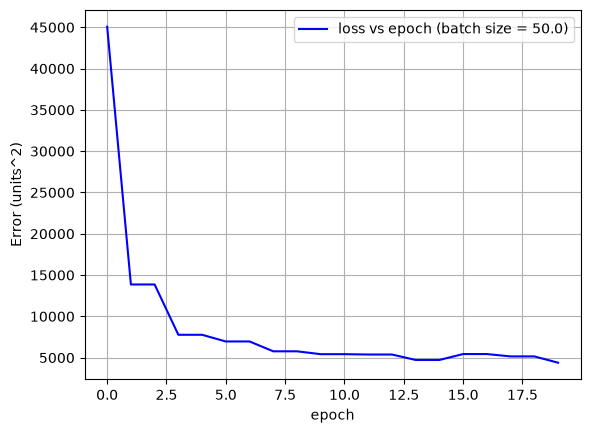

In [50]:
plt.plot(total,label=f'loss vs epoch (batch size = {TRAIN_AMOUNT/BATCH_AMOUNT})',color='blue')
plt.xlabel("epoch")
plt.ylabel("Error (units^2)")
plt.legend()
plt.grid(True)

plt.show()